# GeoTIGER: five-address Washington, DC demo

This is the smallest end-to-end GeoTIGER example. It downloads Census TIGER/Line street ranges for Washington, DC, builds a reusable local reference, and geocodes five input rows—including an intersection. The inputs contain no coordinates; GeoTIGER produces latitude/longitude locally.

## What this notebook demonstrates

- download and cache unmodified TIGER/Line data with `pygris`;
- interpolate address candidates in DC's projected State Plane CRS, not in latitude/longitude;
- prepare intersections and ordinary street addresses in one reference;
- geocode an in-memory Pandas table without sending its addresses online; and
- inspect component scores, timings, a static Matplotlib map, and an optional Folium map.

## Run it locally

From the repository root, run `uv sync --extra demo --extra dev`, then `uv run jupyter lab`. If JupyterLab suppresses saved map output, run `uv run jupyter trust notebooks/dc_five_addresses_demo.ipynb` and reopen it. Trust only permits saved HTML/JavaScript output to render; use **Restart Kernel and Run All Cells** to verify the code on your machine.

The first run needs internet access to download TIGER/Line. Later preparation and geocoding are local, and cached files under `data/dc_demo/` make repeat runs faster. No geocoding API or online address lookup is used. The optional Folium display downloads OpenStreetMap background tiles in your browser; the static map remains fully offline.

In [1]:
from pathlib import Path
from time import perf_counter

import pandas as pd
from IPython.display import display

from geotiger import (
    Geocoder,
    GeoTIGERStore,
    GeocoderConfig,
    InterpolationConfig,
    download_tiger_ranges,
    load_ranges,
    matches_map,
    matches_static_map,
    prepare_ranges,
    state_plane_crs,
)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
CACHE_DIR = PROJECT_ROOT / "data/dc_demo"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RANGES_CACHE = CACHE_DIR / "dc_tiger_ranges.parquet"
PREPARED_CACHE = CACHE_DIR / "dc_tiger_prepared_default_offsets.parquet"
print({"state": "DC", "projection": state_plane_crs("DC")})

{'state': 'DC', 'projection': 'EPSG:2248'}


## 1. Download the local reference data

This is the reference candidate table for the geocoder. It is not the five-row input table. The downloaded TIGER data has street geometry and address ranges, but no precomputed address-point latitude/longitude from an online geocoder.

In [2]:
started = perf_counter()
if RANGES_CACHE.exists():
    ranges = load_ranges(RANGES_CACHE)
    mode = "loaded local cache"
else:
    ranges = download_tiger_ranges("DC", county="001", year=2024, cache=True)
    ranges.to_parquet(RANGES_CACHE)
    mode = "downloaded and cached"
print({"mode": mode, "range_rows": len(ranges), "seconds_this_run": round(perf_counter() - started, 3)})

{'mode': 'loaded local cache', 'range_rows': 13267, 'seconds_this_run': 0.068}


## 2. Prepare the ranges in a local projected CRS

Interpolation uses DC's Maryland State Plane US-foot CRS (`EPSG:2248`), rather than latitude/longitude. This example keeps GeoTIGER's normal 5 m endpoint and 5 m side offsets; only the Durham block-midpoint demo uses zero offsets. The output keeps latitude/longitude for the final geocoding result.

In [3]:
prep_started = perf_counter()
if PREPARED_CACHE.exists():
    prepared = pd.read_parquet(PREPARED_CACHE)
    prep_mode = "loaded local cache"
else:
    prepared = prepare_ranges(
        ranges,
        state="DC",
        source="tiger_2024_dc",
        config=InterpolationConfig(projected_crs=state_plane_crs("DC")),
    )
    prepared.to_parquet(PREPARED_CACHE)
    prep_mode = "prepared and cached"
print({
    "mode": prep_mode,
    "prepared_rows": len(prepared),
    "intersection_rows": int(prepared["is_intersection"].sum()),
    "interpolation_crs": prepared["interpolation_crs"].iloc[0],
    "end_offset_m": InterpolationConfig().end_offset_m,
    "side_offset_m": InterpolationConfig().side_offset_m,
    "seconds_this_run": round(perf_counter() - prep_started, 3),
})

{'mode': 'prepared and cached', 'prepared_rows': 1074349, 'intersection_rows': 7631, 'interpolation_crs': 'EPSG:2248', 'end_offset_m': 5.0, 'side_offset_m': 5.0, 'seconds_this_run': 28.911}


## 3. Geocode five addresses with no coordinate input

These are ordinary address records. The output fields `match_latitude` and `match_longitude` are generated from the locally prepared TIGER candidates.

In [4]:
inputs = pd.DataFrame([
    {"record_id": 1, "address": "1600 Pennsylvania Avenue NW", "city": "Washington", "state": "DC", "zip": "20500"},
    {"record_id": 2, "address": "700 Pennsylvania Avenue SE", "city": "Washington", "state": "DC", "zip": "20003"},
    {"record_id": 3, "address": "400 4th Street SW", "city": "Washington", "state": "DC", "zip": "20024"},
    {"record_id": 4, "address": "1200 New York Avenue NW", "city": "Washington", "state": "DC", "zip": "20005"},
    {"record_id": 5, "address": "2 Independence Avenue SW", "city": "Washington", "state": "DC", "zip": "20024"},
])

store = GeoTIGERStore(":memory:", threads=4)
store.create()
store.ingest_candidates(prepared)
result = Geocoder(
    store,
    config=GeocoderConfig(
        strict_locality=False,
        street_fallback=False,
        deduplicate_inputs=True,
    ),
).geocode(inputs)
print(result.timings.to_dict())
display(result.matches[[
    "record_id", "address", "match_status", "matched_address_id",
    "score", "match_latitude", "match_longitude",
]])

{'input_count': 5, 'candidate_count': 17, 'lookup_hit_count': 0, 'history_cache_hit_count': 0, 'matched_count': 5, 'review_count': 0, 'unmatched_count': 0, 'parse_seconds': 0.020785, 'lookup_seconds': 0.029053, 'history_cache_seconds': 0.025026, 'candidate_query_seconds': 0.155924, 'scoring_seconds': 0.02893, 'aggregation_seconds': 0.025035, 'total_seconds': 0.292065, 'throughput_per_second': 17.12, 'deduplicate_inputs': True, 'candidate_input_count': 5, 'candidate_query_input_count': 5, 'duckdb_threads': 4, 'python': '3.12.12', 'platform': 'Windows-10-10.0.19045-SP0'}


,record_id,address,match_status,matched_address_id,score,match_latitude,match_longitude
0,1,1600 Pennsylvania Avenue NW,matched,tiger_2024_dc:76225813:L:1600,100.000,38.898703,-77.036545
1,2,700 Pennsylvania Avenue SE,matched,tiger_2024_dc:641474058:R:699,99.956,38.884535,-76.996252
2,3,400 4th Street SW,matched,tiger_2024_dc:76226966:L:400,100.000,38.883880,-77.017498
3,4,1200 New York Avenue NW,matched,tiger_2024_dc:76226156:L:1200,100.000,38.900685,-77.028102
4,5,2 Independence Avenue SW,matched,tiger_2024_dc:76226835:L:2,100.000,38.887543,-77.009988


## 4. Map the generated coordinates

The first cell below is the fully offline static Matplotlib output for reports. The next cell is a separate interactive Folium output with an OpenStreetMap background. Loading those public map tiles makes browser requests, but the address parsing and geocoding remain local.

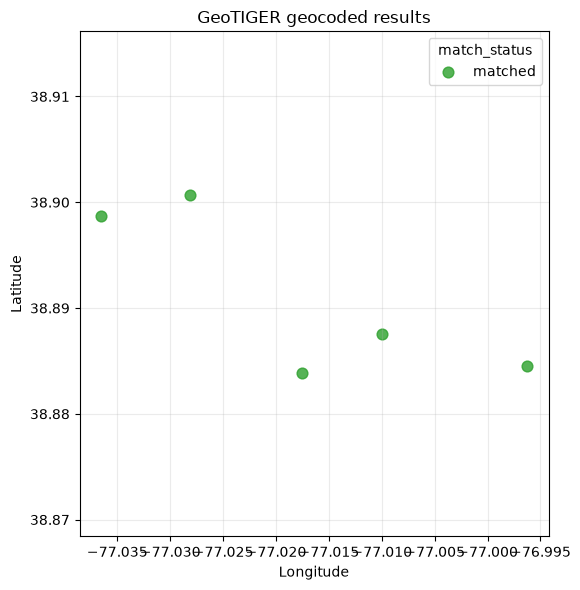

In [5]:
static_axes = matches_static_map(result.matches, figsize=(6, 6), point_size=60)
static_axes.figure.tight_layout()

In [6]:
interactive_map = matches_map(result.matches, tiles='OpenStreetMap', zoom_start=12)
interactive_map